# DS4200 Homework 9

Due: Friday Apr 3rd @ 11:59 PM EST

### Submission Instructions
Submit this `ipynb` file included with the coding results to Gradescope (this can also be done via the assignment on Canvas).  To ensure that your submitted files represent your latest code, make sure to give a fresh `Kernel > Restart & Run All` just before uploading the files to gradescope.

### Tips for success
- Start early
- Make use of Piazza
- Make use of Office hour
- Remember to use cells and headings to make the notebook easy to read (if a grader cannot find the answer to a problem, you will receive no points for it)
- Under no circumstances may one student view or share their ungraded homework or quiz with another student [(see also)](http://www.northeastern.edu/osccr/academic-integrity), though you are welcome to **talk about** (not show each other) the problems.

### Part 1 Analysis the Wolfe Primates

These data represent 3 months of interactions among a troop of monkeys, observed in the wild by Linda Wolfe as they sported by a river in Ocala, Florida. Joint presence at the river was coded as an interaction and these were summed within all pairs. 

There are two files for the data. `labels.csv` is the file contains information for each monkey, with their genders, ages and their rank in the troop. `link_m.csv` is the file contains the number of their interaction in the adjacency matrix format. Note, there is no header in hte `link_m.csv`.

#### Part 1.1 Visualize the adjacency matrix (10 points)

Load the data and **reorder the link matrix based on rank**. For example, suppose the original data table is:

|   | ID | Sex    | Age | Rank |
|--:|---:|--------|----:|------|
| 0 |  0 | female |  12 |    3 |
| 1 |  1 | male   |   9 |    2 |
| 2 |  2 | male   |  15 |    1 |
| 3 |  3 | male   |   7 |    5 |
| 4 |  4 | female |   4 |    4 |

You should reorder **both the rows and columns** of the `link_m` matrix according to the rank order `[3, 2, 1, 5, 4]`. Note that the rank values start at **1**, while matrix indices start at **0**, so you must subtract **1** from each rank value before using it as an index for reordering.

Finally, provide an appropriate **title** and **axis labels** for the resulting plot.
        

In [24]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [25]:
labels = pd.read_csv('labels.csv')
labels.head()

,Id,Sex,Age,Rank
0,0,male,15,1
1,1,male,10,2
2,2,male,10,3
3,3,male,8,4
4,4,male,7,5


In [26]:
link_m = pd.read_csv('link_m.csv', header = None)
link_m

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0,2,10,4,5,5,9,7,4,3,3,7,3,2,5,1,4,1,0,1
1,2,0,5,1,3,1,4,2,6,2,5,4,3,2,2,6,3,1,1,1
2,10,5,0,8,9,5,11,7,8,8,14,17,9,11,11,5,9,4,6,5
3,4,1,8,0,4,0,3,4,2,3,5,3,11,4,7,0,4,3,3,0
4,5,3,9,4,0,3,5,7,4,3,5,6,3,4,4,1,2,1,3,3
5,5,1,5,0,3,0,5,2,3,2,2,4,4,3,1,1,2,0,1,2
6,9,4,11,3,5,5,0,5,4,6,3,9,5,5,4,2,6,3,2,2
7,7,2,7,4,7,2,5,0,3,0,3,4,2,1,3,0,1,1,1,0
8,4,6,8,2,4,3,4,3,0,1,3,2,4,5,4,3,4,1,3,2
9,3,2,8,3,3,2,6,0,1,0,4,7,5,5,7,2,2,3,3,2


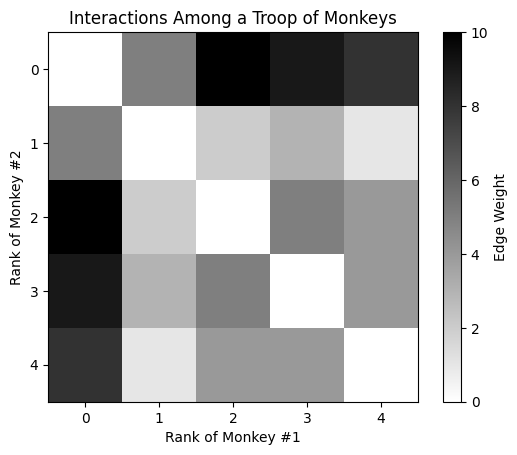

In [27]:
rank_order = [2, 1, 0, 4, 3]
new_link_m = link_m.reindex(index=rank_order, columns=rank_order)
plt.imshow(new_link_m, cmap='binary', interpolation='none')

plt.title("Interactions Among a Troop of Monkeys")
plt.xlabel("Rank of Monkey #1")
plt.ylabel("Rank of Monkey #2")
plt.colorbar(label='Edge Weight')

plt.show()

#### Part 1.2 edgelist (10 points)

Convert the data into an **edge list data frame** with three columns: **source**, **target**, and **weight**. The **source** and **target** columns should contain the IDs of the monkeys, and the **weight** column should store the corresponding values from the link matrix, representing the number of interactions between each pair of monkeys.


In [28]:
edge_list = link_m.stack().reset_index()
edge_list.columns = ['source', 'target', 'weight']
edge_list

,source,target,weight
0,0,0,0
1,0,1,2
2,0,2,10
3,0,3,4
4,0,4,5
...,...,...,...
395,19,15,1
396,19,16,3
397,19,17,1
398,19,18,6


#### Part 1.3 Make a static network (15 points)

Using the edge list generated in **Part 1.2**, construct a **bipartite network** in which one partition represents **male** nodes and the other represents **female** nodes. Encode **gender** using node color and **age** using node size. Encode **edge weight** using the width of the links. You may adjust the scaling of node sizes and edge widths as needed to ensure the network is visually clear and interpretable.

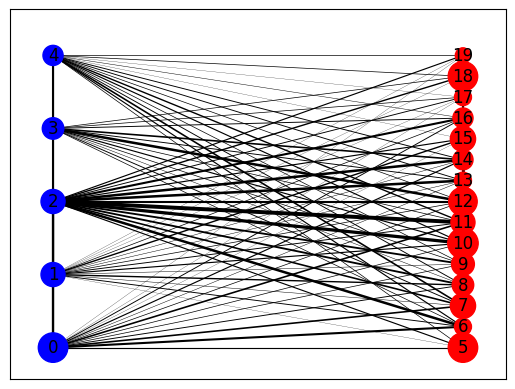

In [29]:
male_monkeys = labels[labels['Sex'] == 'male']['Id'].tolist()
female_monkeys = labels[labels['Sex'] == 'female']['Id'].tolist()
G = nx.from_pandas_edgelist(df=edge_list, source='source', target='target', edge_attr='weight')

pos = nx.bipartite_layout(G, male_monkeys)

node_colors = ['blue' if node in male_monkeys else 'red' for node in G.nodes()]
node_sizes = [labels[labels['Id'] == node]['Age'].values[0] * 30 for node in G.nodes()]

edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_edges(G, pos, width=[w/6 for w in weights])
nx.draw_networkx_labels(G, pos)
plt.show()

### Part 2 Brokerage and Closure in social networks (25 points)

#### Part 2.1 Concepts (5 points)

Use an AI tool (e.g., ChatGPT) to learn about the concepts of brokerage and closure in social networks. In your **own words**, briefly describe:
- What is **closure** in a social network?
- What is **brokerage** in a social network?
- Highlight **at least two key differences** between these two concepts. (Hint: a network with more closure vs. a network with more brokerage, how would they be different from each other? If I randomly remove a link from the network, what will happen to each type of the network?)


Closure in a social network refers to a network where individuals are very closely connected, meaning most individuals in said network know each other already. Brokerage is when a certain individual in a network connects disconnected groups and individuals. Networks with more closure are more densely connected, while those with more brokerage are more fragmented/sparsely connected. Additionally, networks with closure have more trust and stability as everyone knows each other, while networks with brokerage can be more innovative as they bridge gaps between people.

#### Part 2.2 Simulation (5 points)

Use AI to help you generate **two adjacency matrices**:
- A matrix representing **a closure-based network**
- A matrix representing **a brokerage-based network**
Requirements:
- Each matrix should represent a network with **at least 10 nodes**
- Make sure your nodes have **labels** (row names and column names), either by names or IDs
- **Save each matrix in a seperate csv file. Attach the csv file in the homework submission.**

#### Part 2.3 Visualization (10 points)

For each of the adjacency matrix:
- Load the adjacency matrix
- Convert the adjacency matrix into an **edge list** format.
- Plot a **static network visualization** representing your social network.

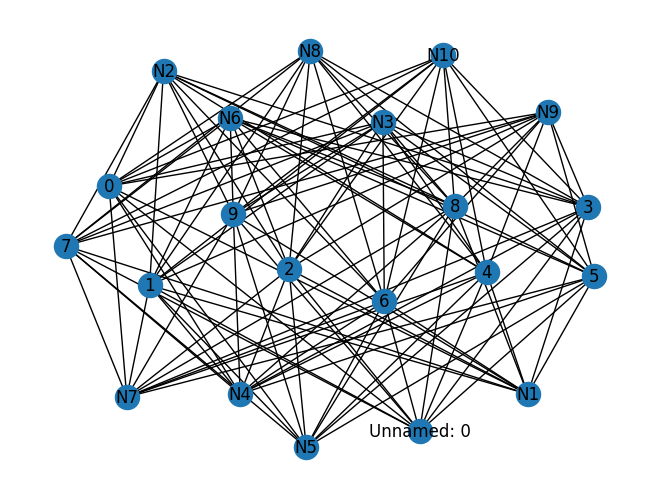

In [30]:
closure = pd.read_csv('closure_network.csv')
brokerage = pd.read_csv('brokerage_network.csv')

closure_edge_list = closure.stack().reset_index()
brokerage_edge_list = brokerage.stack().reset_index()

closure_edge_list.columns = ['source', 'target', 'weight']
closure_edge_list = closure_edge_list[closure_edge_list['weight'] != '0']
brokerage_edge_list.columns = ['source', 'target', 'weight']
brokerage_edge_list =brokerage_edge_list[closure_edge_list['weight'] != '0']

G_closure = nx.from_pandas_edgelist(closure_edge_list, source='source', target='target')
G_brokerage = nx.from_pandas_edgelist(brokerage_edge_list, source='source', target='target')

nx.draw(G_closure, with_labels=True)

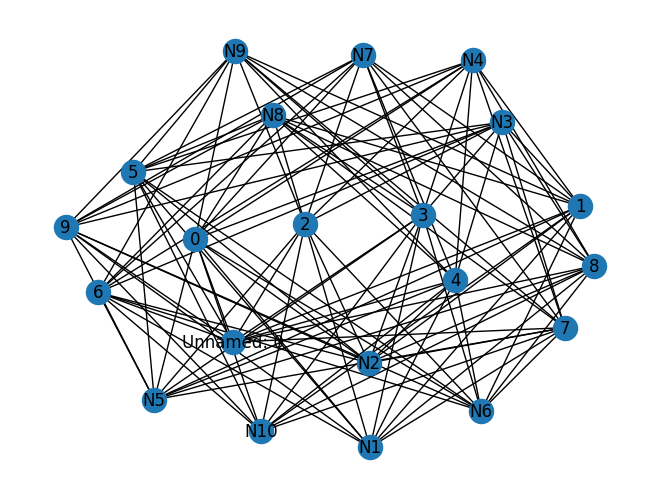

In [31]:
nx.draw(G_brokerage, with_labels=True)

#### Part 2.4 Reflection and Application (5 points)

Write a short reflection (1–2 paragraphs):
- In what real-life situations are you more likely to observe:
    - Closure-based networks?
    - Brokerage-based networks?
- Which type of network is closer to your own social network?

Some situations where closure-based networks are more likely to be observed is exclusive organizations like fraternities and sororities. In such situations, these organizations have very strict entry and membership requirements. As a result, these are more likely to be closure-based because they act like closed environments. For example, if a new person joined a fraternity, then all the other members would get to know that there is a new member.
Some situations where brokerage-based networks are more likely to be observed are open social situations like schools, universities, companies, communities, and neighborhoods. These situations are where there is a lot of intermingling of different groups. For example, in schools and universities, you have different classes with different classmates; you having a friend in one class and a different friend in another class means that you become the link between these two people.

I think my network is more like a brokerage network. Although there are parts of my network that could resemble more of a closure network, such as having friends from my hometown but going to a university in a different town, they all still come together to become a more brokerage-based network. For example, I am a link between my friends from school and my friends from my college. Another example is that I have friends who are friends with other people, meaning they are the link between me and their other friends.